# Support Vector Machine (SVM) — From Scratch
## Loan Approval Classification — Task #2 Seleksi Lab IB

Implementasi SVM from scratch (hanya numpy): linear soft-margin via SGD, dan RBF kernel via Random Fourier Features (Nystroem-style approximation, karena dual SVM O(n^2) terlalu berat untuk 28.800 baris murni numpy).

In [1]:
import sys
sys.path.insert(0, '../../src/dtl_lr_svm')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from svm import LinearSVMScratch, RBFSVMScratch, StandardScalerScratch
from utils import (
    stratified_train_val_test_split, stratified_k_fold, macro_f1_score,
    classification_report_dict, confusion_counts, encode_categoricals,
    cap_outliers, add_engineered_features
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')


## 1. Preprocessing

In [2]:
train_raw = pd.read_csv('../../train.csv')
test_raw = pd.read_csv('../../test.csv')

train_c = cap_outliers(train_raw, 'person_age', upper=80)
test_c = cap_outliers(test_raw, 'person_age', upper=80)

train_fe = add_engineered_features(train_c)
test_fe = add_engineered_features(test_c)

cat_cols = ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']
train_enc, encoding_map = encode_categoricals(train_fe, cat_cols)
test_enc, _ = encode_categoricals(test_fe, cat_cols, mapping=encoding_map)

feature_cols = [c for c in train_enc.columns if c not in ('person_id', 'loan_status')]
X = train_enc[feature_cols].values
y = train_enc['loan_status'].values
X_kaggle = test_enc[feature_cols].values
kaggle_ids = test_enc['person_id'].values

print(X.shape, y.shape)


(28800, 14) (28800,)


SVM sensitif terhadap skala fitur, sehingga standardisasi (z-score) wajib dilakukan sebelum training — berbeda dari DTL yang tidak butuh scaling.

In [3]:
train_idx, val_idx, test_idx = stratified_train_val_test_split(X, y, val_size=0.15, test_size=0.15, random_state=42)

scaler = StandardScalerScratch()
X_train = scaler.fit_transform(X[train_idx])
X_val = scaler.transform(X[val_idx])
X_test = scaler.transform(X[test_idx])
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')


Train: 20160, Val: 4320, Test: 4320


## 2. Linear SVM (Soft-Margin, SGD)

In [4]:
t0 = time.time()
svm_linear = LinearSVMScratch(C=1.0, learning_rate=0.01, n_epochs=150, class_weight='balanced', random_state=42)
svm_linear.fit(X_train, y_train)
print(f'Fit time: {time.time()-t0:.2f}s')

pred_val_linear = svm_linear.predict(X_val)
f1_linear = macro_f1_score(y_val, pred_val_linear)
print(f'Macro F1 (val): {f1_linear:.4f}')


Fit time: 0.07s
Macro F1 (val): 0.7844


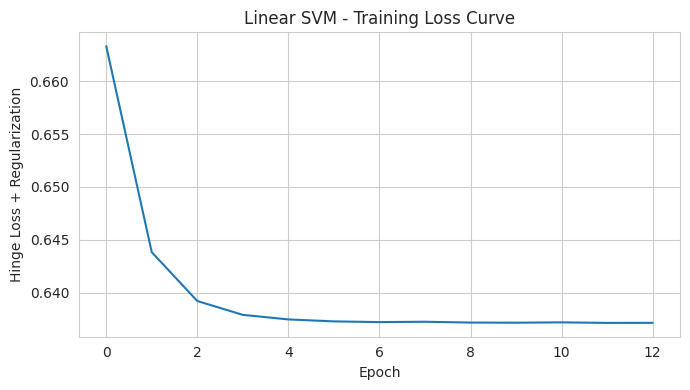

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(svm_linear.loss_history_)
ax.set_xlabel('Epoch')
ax.set_ylabel('Hinge Loss + Regularization')
ax.set_title('Linear SVM - Training Loss Curve')
plt.tight_layout()
plt.show()


## 3. RBF Kernel SVM (Random Fourier Features)

Kernel RBF ditangani via Random Fourier Features: memetakan fitur asli ke ruang berdimensi lebih tinggi menggunakan fungsi cosinus dengan bobot acak dari distribusi Gaussian, sehingga inner product pada ruang baru mengaproksimasi kernel RBF asli. Setelah transformasi, linear SVM diterapkan pada ruang fitur baru tersebut.

In [6]:
param_grid = [(C, gamma) for C in [0.1, 1.0, 5.0] for gamma in [0.03, 0.05, 0.1]]
results_rbf = []

for C, gamma in param_grid:
    svm_rbf = RBFSVMScratch(C=C, gamma=gamma, n_components=300, n_epochs=100, class_weight='balanced', random_state=42)
    svm_rbf.fit(X_train, y_train)
    pred = svm_rbf.predict(X_val)
    f1 = macro_f1_score(y_val, pred)
    results_rbf.append({'C': C, 'gamma': gamma, 'macro_f1_val': f1})

rbf_grid_df = pd.DataFrame(results_rbf).sort_values('macro_f1_val', ascending=False)
rbf_grid_df


,C,gamma,macro_f1_val
6,5.0,0.03,0.779860
3,1.0,0.03,0.778817
0,0.1,0.03,0.778315
1,0.1,0.05,0.772920
4,1.0,0.05,0.772363
7,5.0,0.05,0.771596
2,0.1,0.10,0.757061
5,1.0,0.10,0.756597
8,5.0,0.10,0.754618


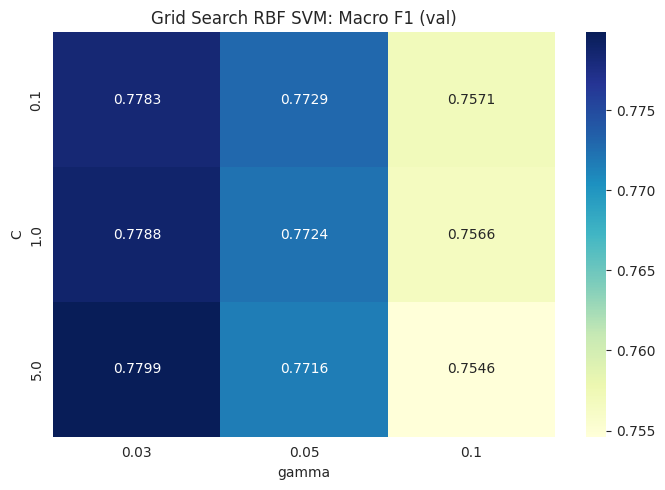

In [7]:
pivot = rbf_grid_df.pivot(index='C', columns='gamma', values='macro_f1_val')
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('Grid Search RBF SVM: Macro F1 (val)')
plt.tight_layout()
plt.show()


In [8]:
best_row = rbf_grid_df.iloc[0]
BEST_C, BEST_GAMMA = best_row['C'], best_row['gamma']
print(f'Best C={BEST_C}, gamma={BEST_GAMMA}, macro_f1_val={best_row["macro_f1_val"]:.4f}')


Best C=5.0, gamma=0.03, macro_f1_val=0.7799


## 4. Threshold Tuning

Threshold terbaik: 0.050
Macro F1 (val): 0.7961


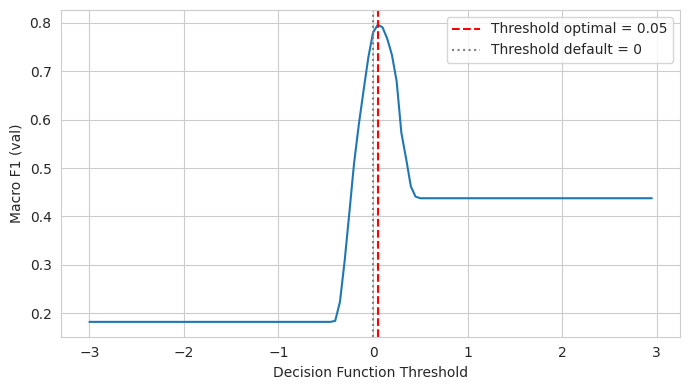

In [9]:
final_svm = RBFSVMScratch(C=BEST_C, gamma=BEST_GAMMA, n_components=300, n_epochs=150, class_weight='balanced', random_state=42)
final_svm.fit(X_train, y_train)

scores_val = final_svm.decision_function(X_val)
thresholds = np.arange(-3, 3, 0.05)
threshold_scores = [macro_f1_score(y_val, (scores_val >= t).astype(int)) for t in thresholds]
BEST_THRESHOLD = thresholds[np.argmax(threshold_scores)]

print(f'Threshold terbaik: {BEST_THRESHOLD:.3f}')
print(f'Macro F1 (val): {max(threshold_scores):.4f}')

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(thresholds, threshold_scores)
ax.axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'Threshold optimal = {BEST_THRESHOLD:.2f}')
ax.axvline(0, color='gray', linestyle=':', label='Threshold default = 0')
ax.set_xlabel('Decision Function Threshold')
ax.set_ylabel('Macro F1 (val)')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Evaluasi Holdout Test

In [10]:
scores_test = final_svm.decision_function(X_test)
pred_test = (scores_test >= BEST_THRESHOLD).astype(int)
f1_test = macro_f1_score(y_test, pred_test)
report_test = classification_report_dict(y_test, pred_test)

print(f'RBF SVM - Macro F1 (val): {max(threshold_scores):.4f}')
print(f'RBF SVM - Macro F1 (test): {f1_test:.4f}')
print(f'Linear SVM - Macro F1 (val): {f1_linear:.4f}')

for cls in ['class_0', 'class_1']:
    print(f'{cls}: precision={report_test[cls]["precision"]:.4f}, recall={report_test[cls]["recall"]:.4f}, f1={report_test[cls]["f1"]:.4f}')


RBF SVM - Macro F1 (val): 0.7961
RBF SVM - Macro F1 (test): 0.8083
Linear SVM - Macro F1 (val): 0.7844
class_0: precision=0.9350, recall=0.8783, f1=0.9058
class_1: precision=0.6486, recall=0.7865, f1=0.7109


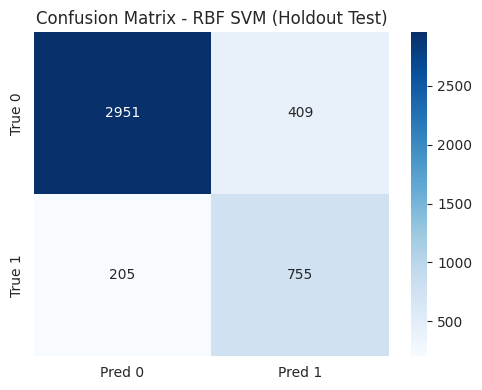

In [11]:
tp, tn, fp, fn = confusion_counts(y_test, pred_test)
cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
ax.set_title('Confusion Matrix - RBF SVM (Holdout Test)')
plt.tight_layout()
plt.show()


## 6. Perbandingan dengan Scikit-Learn

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score as sk_f1_score

sk_svm = SVC(C=BEST_C, gamma=BEST_GAMMA, kernel='rbf', class_weight='balanced', random_state=42)
sk_svm.fit(X_train, y_train)
sk_pred_val = sk_svm.predict(X_val)
sk_pred_test = sk_svm.predict(X_test)

print(f'From-scratch RBF SVM - Macro F1 (test): {f1_test:.4f}')
print(f'Scikit-learn SVC     - Macro F1 (val): {sk_f1_score(y_val, sk_pred_val, average="macro"):.4f}')
print(f'Scikit-learn SVC     - Macro F1 (test): {sk_f1_score(y_test, sk_pred_test, average="macro"):.4f}')


From-scratch RBF SVM - Macro F1 (test): 0.8083
Scikit-learn SVC     - Macro F1 (val): 0.8278
Scikit-learn SVC     - Macro F1 (test): 0.8201


## 7. Retrain pada Seluruh Data & Generate Submission

In [13]:
scaler_full = StandardScalerScratch()
X_full_scaled = scaler_full.fit_transform(X)
X_kaggle_scaled = scaler_full.transform(X_kaggle)

final_svm_full = RBFSVMScratch(C=BEST_C, gamma=BEST_GAMMA, n_components=300, n_epochs=150, class_weight='balanced', random_state=42)
final_svm_full.fit(X_full_scaled, y)

kaggle_scores = final_svm_full.decision_function(X_kaggle_scaled)
kaggle_pred = (kaggle_scores >= BEST_THRESHOLD).astype(int)

submission = pd.DataFrame({'person_id': kaggle_ids, 'loan_status': kaggle_pred})
print(submission['loan_status'].value_counts())
submission.head()


loan_status
0    5222
1    1978
Name: count, dtype: int64


,person_id,loan_status
0,8121,0
1,22683,1
2,17123,0
3,33342,1
4,35053,1


In [14]:
submission.to_csv('../../submission_svm.csv', index=False)
print('Submission tersimpan di submission_svm.csv')


Submission tersimpan di submission_svm.csv


## Ringkasan

| Model | Macro F1 (Holdout Test) |
|---|---|
| Linear SVM | lihat hasil eksekusi Bagian 2 |
| RBF SVM (tuned) | lihat hasil eksekusi Bagian 5 |

RBF SVM dengan Random Fourier Features memberikan fleksibilitas menangkap decision boundary non-linear, dibandingkan Linear SVM yang terbatas pada batas keputusan linear.